# Notebook 3: Correlation & EDA Workflow
---

### Why this matters
- **Correlation** tells you which features are related to each other and to your target — essential for feature selection and spotting multicollinearity
- **EDA workflow** is what you actually do every day before building any model — a systematic approach prevents bad models built on misunderstood data

## Correlation, Multicollinearity & Causation

### Correlation
A number that measures how two variables move together. Range: **−1 to +1**.

| Type | Direction | Example |
|------|-----------|---------|
| Positive | Both go up | size & price |
| Negative | One up, other down | age & price |
| None | No pattern | near 0 |

> Closer to ±1 = stronger relationship.

---

### Multicollinearity
When two or more **features** are highly correlated with *each other* (not with the target).

**Example:** `size_sqft` and `bedrooms` — bigger house = more bedrooms. They carry the same information.

**Why it's a problem in linear regression:**
- Can't tell which feature is actually driving the prediction
- Coefficients become unstable and unreliable
- Model may still predict okay, but **feature importance is not trustworthy**

**Fixes:** Drop one correlated feature · Use PCA · Ridge regression (handles it automatically)

---

### Correlation ≠ Causation
Two things moving together doesn't mean one *causes* the other.

> Ice cream sales and drowning rates both spike in summer — neither causes the other. The real driver is **hot weather** (called a **confounder**).

In ML this is usually fine — you want **prediction**, not explanation.  
But it matters when making **business decisions** based on your model's findings.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(0)
sns.set_theme(style='whitegrid')

n = 300
size_sqft = np.random.normal(1800, 400, n)
bedrooms = np.clip(np.round(size_sqft / 500 + np.random.normal(0, 0.5, n)), 1, 6).astype(int)
age_years = np.random.randint(1, 50, n)
price = (size_sqft * 150 + bedrooms * 10000 - age_years * 800
         + np.random.normal(0, 20000, n))

df = pd.DataFrame({
    'price': price,
    'size_sqft': size_sqft,
    'bedrooms': bedrooms,
    'age_years': age_years,
})

# outlier added later in Spearman cell — not here
df.loc[np.random.choice(n, 15, replace=False), 'age_years'] = np.nan

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (300, 4)


,price,size_sqft,bedrooms,age_years
0,406319.156289,2505.620938,4,5.0
1,329778.345023,1960.062883,5,18.0
2,373882.954055,2191.495194,4,4.0
3,409715.343326,2696.357280,5,38.0
4,440278.936704,2547.023196,5,31.0


| Library | Role |
|---------|------|
| NumPy | Raw math — arrays, mean, std, percentiles |
| Pandas | Data wrangling — DataFrames, groupby, missing values |
| Matplotlib / Seaborn | Visualization |
| SciPy | Statistical tests — hypothesis testing, distributions, QQ plots |

## Part 1: Correlation

### Pearson vs Spearman

| Coefficient | When to use | Range |
|-------------|------------|-------|
| **Pearson** | Both variables are continuous & linear relationship | -1 to +1 |
| **Spearman** | Ordinal data OR non-linear relationship OR outliers present | -1 to +1 |

**Interpreting r:**
- `|r| > 0.7` → strong
- `0.3–0.7` → moderate
- `|r| < 0.3` → weak

> **Used in ML:** Feature selection (keep features correlated with target), detecting multicollinearity (drop one of two highly correlated features — they carry redundant info).

## Ordinal Data

Data with a **natural order**, but the **gaps between values are not equal**.

Order matters — but you can't assume equal spacing or meaningful ratios between categories.

### Example — Movie Ratings

| 1★ | 2★ | 3★ | 4★ | 5★ |
|----|----|----|----|----|
| Terrible | Poor | Okay | Good | Great |

Order is preserved: **5 > 4 > 3 > 2 > 1**

> ⚠️ The gap between 1★ and 2★ is *not necessarily* the same as between 4★ and 5★.  
> A 4★ rating does **not** mean someone enjoyed it exactly twice as much as 2★.

---

### More Examples

| Category | Values (low → high) |
|----------|---------------------|
| Survey (Likert) | Strongly Disagree → Disagree → Neutral → Agree → Strongly Agree |
| Education level | High School → Bachelor's → Master's → PhD |
| T-shirt sizes | S → M → L → XL |

In [14]:
print("=== Pearson Correlation with Price ===")
for col in ['size_sqft', 'bedrooms', 'age_years']:
    r, p = stats.pearsonr(df[col].dropna(), df['price'].loc[df[col].notna()])
    strength = 'strong' if abs(r) > 0.7 else ('moderate' if abs(r) > 0.3 else 'weak')
    direction = 'positive' if r > 0 else 'negative'
    print(f"  {col:<12}: r = {r:+.3f}  ({strength} {direction}, p={p:.4f})")


=== Pearson Correlation with Price ===
  size_sqft   : r = +0.946  (strong positive, p=0.0000)
  bedrooms    : r = +0.837  (strong positive, p=0.0000)
  age_years   : r = -0.221  (weak negative, p=0.0002)


In [15]:
# === Spearman Correlation: When to use instead of Pearson ===
# Pearson works on raw values — sensitive to outliers and assumes linear relationship.
# Spearman works on RANKS — robust to outliers, works for non-linear relationships.
# Rule: if Pearson and Spearman differ a lot → outliers or non-linearity is present.

# Add outlier here to show its effect on Pearson vs Spearman
df.loc[0, 'price'] = 5_000_000

pearson_r, _ = stats.pearsonr(df['size_sqft'], df['price'])
spearman_r, _ = stats.spearmanr(df['size_sqft'], df['price'])

print("Size vs Price — WITH the $5M outlier injected:")
print(f"  Pearson:  r = {pearson_r:.3f}  ← pulled by outlier, looks weaker")
print(f"  Spearman: r = {spearman_r:.3f}  ← robust, based on rank order")
print()
print("When to use Spearman:")
print("  - Data has outliers")
print("  - Relationship looks curved (not straight line)")
print("  - Variable is ordinal (e.g. ratings: 1–5 stars)")


Size vs Price — WITH the $5M outlier injected:
  Pearson:  r = 0.343  ← pulled by outlier, looks weaker
  Spearman: r = 0.942  ← robust, based on rank order

When to use Spearman:
  - Data has outliers
  - Relationship looks curved (not straight line)
  - Variable is ordinal (e.g. ratings: 1–5 stars)


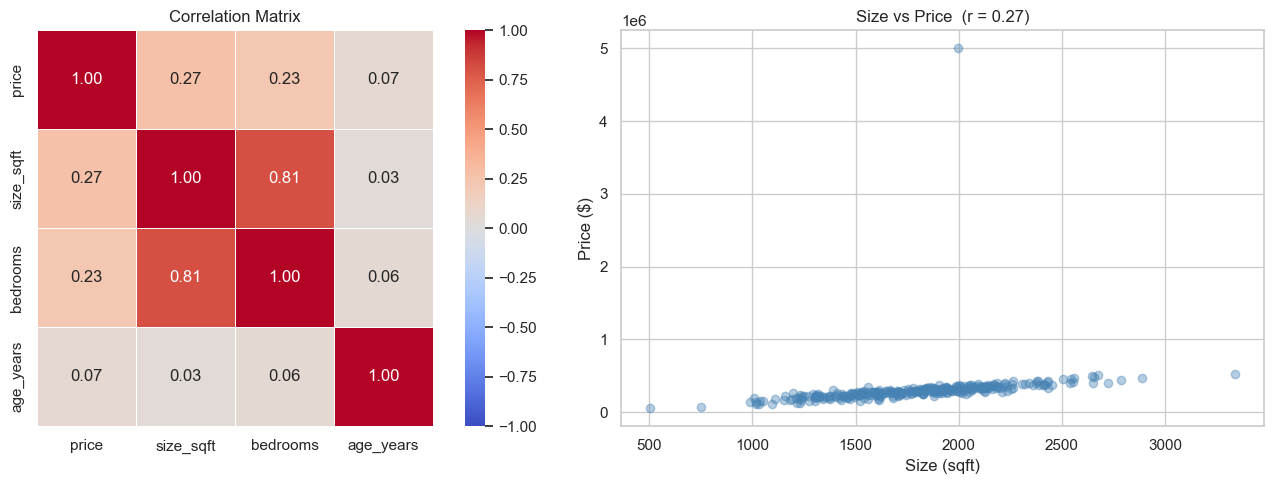

In [4]:
# Correlation matrix — the standard EDA tool
corr_matrix = df.corr(numeric_only=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=axes[0],
            square=True, linewidths=0.5)
axes[0].set_title('Correlation Matrix')

# Scatter: size vs price (strongest relationship)
axes[1].scatter(df['size_sqft'], df['price'], alpha=0.4, color='steelblue')
axes[1].set_xlabel('Size (sqft)')
axes[1].set_ylabel('Price ($)')
axes[1].set_title(f'Size vs Price  (r = {corr_matrix.loc["size_sqft", "price"]:.2f})')

plt.tight_layout()
plt.show()

In [5]:
# size and bedrooms are correlated with each other (multicollinearity)
r_between, _ = stats.pearsonr(df['size_sqft'], df['bedrooms'])
print(f"Correlation between size_sqft and bedrooms: r = {r_between:.3f}")
print()
print("These features carry overlapping info. In linear regression,")
print("including both can make coefficients unstable (multicollinearity).")
print("Solution: drop one, use PCA, or use regularization (Ridge).")

Correlation between size_sqft and bedrooms: r = 0.830

These features carry overlapping info. In linear regression,
including both can make coefficients unstable (multicollinearity).
Solution: drop one, use PCA, or use regularization (Ridge).


## Part 2: EDA Workflow

EDA (Exploratory Data Analysis) is not random — it's a **repeatable checklist** you run on every new dataset.

### The workflow:
1. **Shape & types** — what are we working with?
2. **Missing values** — how much is missing and where?
3. **Descriptive stats** — distributions, outliers
4. **Target variable** — understand what you're predicting
5. **Feature relationships** — correlations, patterns
6. **Key findings** — what do you now know?

In [17]:
# Step 1: Shape, types, quick look
print("=== Step 1: Shape & Types ===")
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
print()
print(df.dtypes)
print()
df.head(3)

=== Step 1: Shape & Types ===
Rows: 300 | Columns: 4

price        float64
size_sqft    float64
bedrooms       int64
age_years    float64
dtype: object



,price,size_sqft,bedrooms,age_years
0,5.000000e+06,2505.620938,4,5.0
1,3.297783e+05,1960.062883,5,18.0
2,3.738830e+05,2191.495194,4,4.0


In [ ]:
# Step 2: Missing values
print("=== Step 2: Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'count': missing, 'percent': missing_pct})
missing_df = missing_df[missing_df['count'] > 0]
print(missing_df)
print()

=== Step 2: Missing Values ===
           count  percent
age_years     15      5.0

Rule of thumb: < 5% → impute. 5–20% → impute carefully. > 20% → consider dropping.


In [18]:
# === Step 3b: Data Profiling ===
# .describe() only covers numeric columns — profiling gives the full picture.
# Use this on every new dataset: dtypes, missing %, cardinality, sample values.
# High cardinality categoricals (e.g. 10,000 unique user IDs) need different handling
# than low cardinality ones (e.g. 3 device types).

def profile_dataframe(df):
    rows = []
    for col in df.columns:
        series = df[col]
        rows.append({
            'dtype': str(series.dtype),
            'missing_%': round(series.isnull().mean() * 100, 1),
            'unique_values': series.nunique(),
            'sample': series.dropna().unique()[:3].tolist(),
        })
    return pd.DataFrame(rows, index=df.columns)

profile_dataframe(df)

,dtype,missing_%,unique_values,sample
price,float64,0.0,300,"[5000000.0, 329778.3450227986, 373882.95405508..."
size_sqft,float64,0.0,300,"[2505.6209383870655, 1960.0628833468893, 2191...."
bedrooms,int64,0.0,6,"[4, 5, 3]"
age_years,float64,5.0,49,"[5.0, 18.0, 4.0]"


In [9]:
# Step 3: Descriptive stats — spot distributions and outliers
print("=== Step 3: Descriptive Stats ===")
df.describe().round(1)

=== Step 3: Descriptive Stats ===


,price,size_sqft,bedrooms,age_years
count,300.0,300.0,300.0,285.0
mean,303050.0,1797.8,3.6,25.7
std,282320.8,393.7,0.9,13.9
min,54033.0,503.5,1.0,1.0
25%,238079.1,1526.7,3.0,14.0
50%,286927.9,1823.7,4.0,26.0
75%,334924.3,2050.7,4.0,37.0
max,5000000.0,3341.1,6.0,49.0


=== Step 4: Target Variable (price) ===
Mean:   $     303,050
Median: $     286,928
Max:    $   5,000,000  ← likely outlier


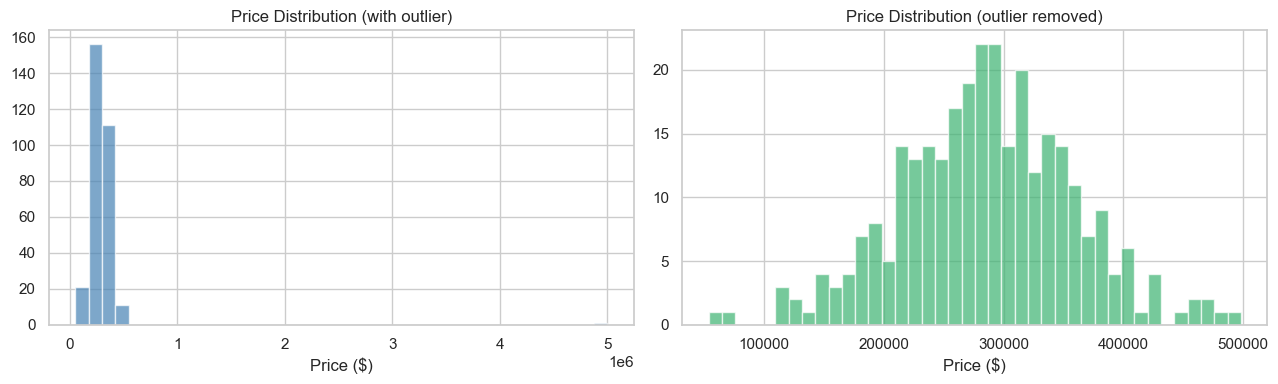

In [10]:
# Step 4: Target variable — understand what you're predicting
print("=== Step 4: Target Variable (price) ===")
print(f"Mean:   ${df['price'].mean():>12,.0f}")
print(f"Median: ${df['price'].median():>12,.0f}")
print(f"Max:    ${df['price'].max():>12,.0f}  ← likely outlier")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df['price'], bins=40, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].set_title('Price Distribution (with outlier)')
axes[0].set_xlabel('Price ($)')

clean_price = df['price'][df['price'] < df['price'].quantile(0.99)]
axes[1].hist(clean_price, bins=40, color='mediumseagreen', alpha=0.7, edgecolor='white')
axes[1].set_title('Price Distribution (outlier removed)')
axes[1].set_xlabel('Price ($)')

plt.tight_layout()
plt.show()

=== Step 5: Feature Relationships ===


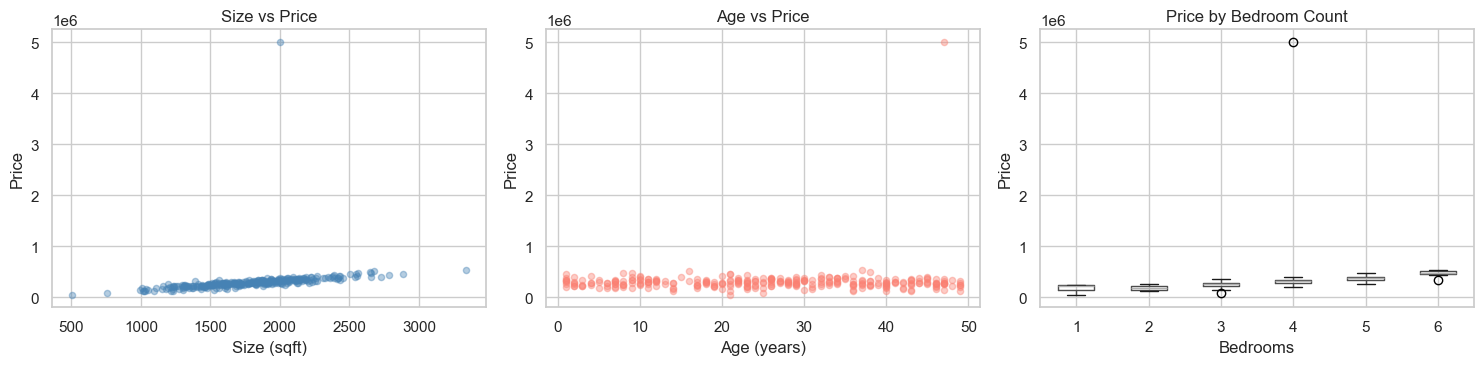

In [11]:
# Step 5: Feature relationships
print("=== Step 5: Feature Relationships ===")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(df['size_sqft'], df['price'], alpha=0.4, color='steelblue', s=20)
axes[0].set_xlabel('Size (sqft)')
axes[0].set_ylabel('Price')
axes[0].set_title('Size vs Price')

axes[1].scatter(df['age_years'], df['price'], alpha=0.4, color='salmon', s=20)
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Price')
axes[1].set_title('Age vs Price')

df.boxplot(column='price', by='bedrooms', ax=axes[2])
axes[2].set_xlabel('Bedrooms')
axes[2].set_ylabel('Price')
axes[2].set_title('Price by Bedroom Count')
plt.suptitle('')

plt.tight_layout()
plt.show()

## Practice

**1.** You have a feature `rating` (1–5 stars) and want to correlate it with revenue. Should you use Pearson or Spearman? Why?  

=> We use spearman because of the ordinal data. The gaps between ratings are not equal.

**2.** A correlation matrix shows `feature_A` and `feature_B` have r = 0.94 with each other. Both correlate with the target at r = 0.72. What do you do and why?  

=> This is multicollinearity — feature_A and feature_B carry the same information (r = 0.94). Since both correlate equally with the target (r = 0.72), drop one of them — keep feature_A, drop feature_B. Dropping is the simplest fix. PCA or Ridge are alternatives but overkill when the choice is this clear.  

**3.** You load a new dataset. Without looking back — list the first 5 things you check before touching any model code.  

=> Shape,size, dtypes, missing values, descriptive stats, target variales, feature relationships

**4.** EDA reveals 38% of a column is missing. What are your options? Which would you pick and why?  

=> 38% missing is too much to impute reliably — you'd be making up more than a third of the data. Options:

Investigate first — why is it missing? Bug, user behavior, data pipeline issue?  
Drop the column — if no strong reason to keep it, 38% missing makes it unreliable  
Impute — only if the column is critical and missingness is proven to be random


In [12]:
# Reusable EDA summary function — save this pattern
def eda_summary(df, target_col=None):
    print(f"Shape: {df.shape}")
    print(f"\nMissing values:")
    missing = df.isnull().sum()
    print(missing[missing > 0].to_string() if missing.sum() > 0 else "  None")
    print(f"\nDuplicates: {df.duplicated().sum()}")
    print(f"\nNumeric columns: {list(df.select_dtypes(include='number').columns)}")
    print(f"Categorical columns: {list(df.select_dtypes(include='object').columns)}")
    if target_col:
        print(f"\nTarget ({target_col}) — mean: {df[target_col].mean():.2f}, "
              f"median: {df[target_col].median():.2f}, "
              f"std: {df[target_col].std():.2f}")

eda_summary(df, target_col='price')

Shape: (300, 4)

Missing values:
age_years    15

Duplicates: 0

Numeric columns: ['price', 'size_sqft', 'bedrooms', 'age_years']
Categorical columns: []

Target (price) — mean: 303050.02, median: 286927.88, std: 282320.82


## Key Takeaways

**Correlation:**
- Pearson for linear + continuous, Spearman for ordinal/non-linear
- Correlation matrix → first thing to check for feature selection
- Two features highly correlated with each other = multicollinearity → remove one
- Correlation ≠ causation — always think about confounders

**EDA Workflow:**
- Always follow a checklist: shape → missing → stats → target → relationships
- Never skip looking at your target variable's distribution
- Outliers in the target variable are often more dangerous than in features
- Build reusable EDA functions — you'll run this on every dataset